# Baseline Model 

**Purpose**: Evaluate the Baseline Model

**Input**: XGB Model, X, y data

In [32]:
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
import joblib
import json
from src.features.engineering import (
    create_features,
    create_gap_label,
    prepare_model_data,
)
from src.config import RANDOM_SEED, TEST_SIZE

In [47]:
PROJECT_DIR = Path.cwd().parent.parent
DATA_FILE = PROJECT_DIR / "data" / "processed" / "ochota_stops_with_amenities.csv"
MODELS_DIR = PROJECT_DIR / "models"
SAVE_DIR = PROJECT_DIR / "artifacts" / "figures" / "notebook03"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [34]:
df = pd.read_csv(DATA_FILE)

df = create_features(df)
df = create_gap_label(df)

X, y = prepare_model_data(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)


In [35]:
model = joblib.load(MODELS_DIR / "xgboost_gap_model.joblib")
with open(MODELS_DIR / "xgboost_gap_model.json") as f:
    metadata = json.load(f)

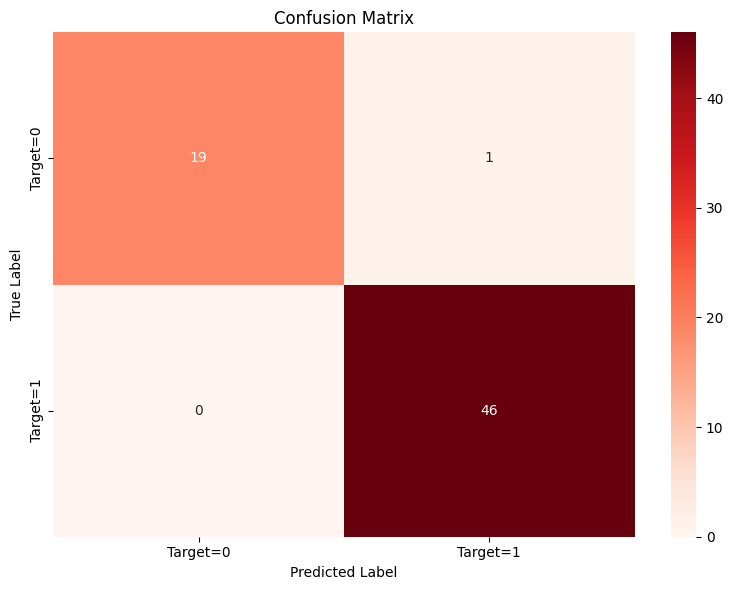

In [49]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    cmap="Reds",
    xticklabels=["Target=0", "Target=1"],
    yticklabels=["Target=0", "Target=1"],
)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(SAVE_DIR / "baseline_model_cm.png")
plt.show()

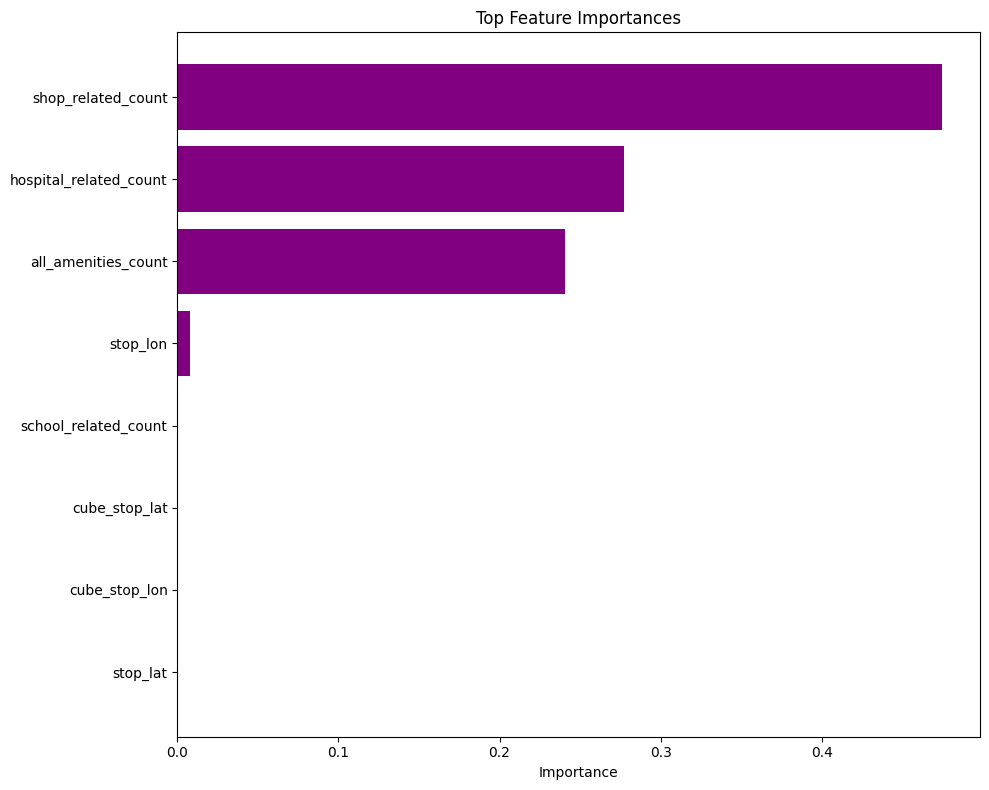

In [50]:
importance = model.feature_importances_
features = metadata["features"]

feat_imp = (
    pd.DataFrame({"feature": features, "importance": importance})
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp["feature"], feat_imp["importance"], color="purple")
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(SAVE_DIR / "baseline_model_top_features.png")
plt.show()

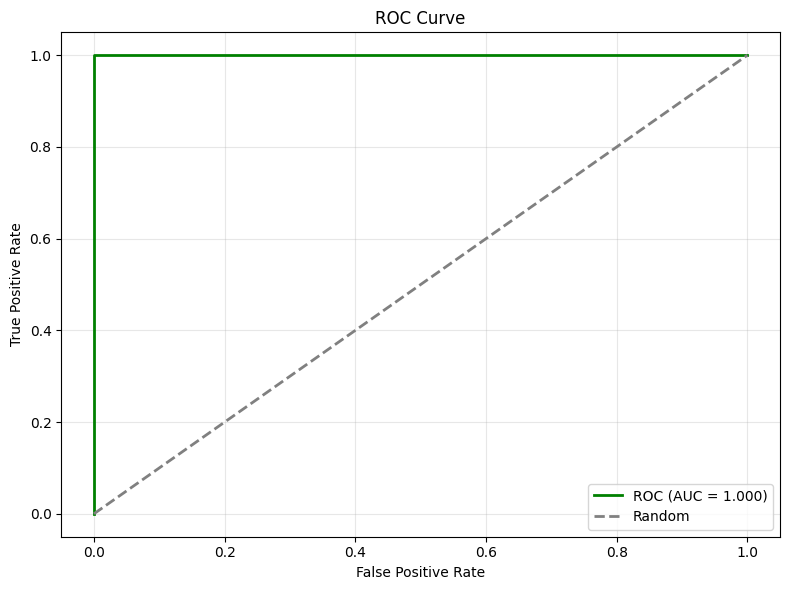

In [51]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="green", lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--", label="Random")
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR / "baseline_model_roc_curve.png")
plt.show()

We see that the model performs so good, that the Area under ROC curve is equal to 1.  